In [184]:
print(sorted(europe["ADMIN"].unique()))

['Albania', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Lithuania', 'Luxembourg', 'Moldova', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Republic of Serbia', 'Romania', 'Russia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom']


In [194]:
# list of countries generated by gemini

countries_label = {
    "Albania": 0,
    "Andorra": 1,
    "Austria": 2,
    "Belarus": 3,
    "Belgium": 4,
    "Bosnia and Herzegovina": 5,
    "Bulgaria": 6,
    "Croatia": 7,
    "Czechia": 8,
    "Denmark": 9,
    "Estonia": 10,
    "Finland": 11,
    "France": 12,
    "Germany": 13,
    "Greece": 14,
    "Hungary": 15,
    "Iceland": 16,
    "Ireland": 17,
    "Italy": 18,
    "Kosovo": 19,
    "Latvia": 20,
    "Liechtenstein": 21,
    "Lithuania": 22,
    "Luxembourg": 23,
    "Malta": 24,
    "Moldova": 25,
    "Monaco": 26,
    "Montenegro": 27,
    "Netherlands": 28,
    "North Macedonia": 29,
    "Norway": 30,
    "Poland": 31,
    "Portugal": 32,
    "Romania": 33,
    "San Marino": 34,
    "Republic of Serbia": 35,
    "Slovakia": 36,
    "Slovenia": 37,
    "Spain": 38,
    "Sweden": 39,
    "Switzerland": 40,
    "Turkey": 41,
    "Ukraine": 42,
    "United Kingdom": 43,
    "Vatican City": 44
}

countries = {
    0: [14, 19, 27, 29],
    1: [12, 38],
    2: [8, 13, 15, 18, 21, 36, 37, 40],
    3: [20, 22, 31, 42],
    4: [12, 13, 23, 28],
    5: [7, 27, 35],
    6: [14, 29, 33, 35, 41],
    7: [5, 15, 27, 35, 37],
    8: [2, 13, 31, 36],
    9: [13],
    10: [20],
    11: [30, 39],
    12: [1, 4, 13, 18, 23, 26, 38, 40],
    13: [2, 4, 8, 9, 12, 23, 28, 31, 40],
    14: [0, 6, 29, 41],
    15: [2, 7, 33, 35, 36, 37, 42],
    16: [],
    17: [43],
    18: [2, 12, 34, 37, 40, 44],
    19: [0, 27, 29, 35],
    20: [3, 10, 22],
    21: [2, 40],
    22: [3, 20, 31],
    23: [4, 12, 13],
    24: [],
    25: [33, 42],
    26: [12],
    27: [0, 5, 7, 19, 35],
    28: [4, 13],
    29: [0, 6, 14, 19, 35],
    30: [11, 39],
    31: [3, 8, 13, 22, 36, 42],
    32: [38],
    33: [6, 15, 25, 35, 42],
    34: [18],
    35: [5, 6, 7, 15, 19, 27, 29, 33],
    36: [2, 8, 15, 31, 42],
    37: [2, 7, 15, 18],
    38: [1, 12, 32],
    39: [11, 30],
    40: [2, 12, 13, 18, 21],
    41: [6, 14],
    42: [3, 15, 25, 31, 33, 36],
    43: [17],
    44: [18]
}


In [123]:
inverse_map = {v: k for k, v in countries_label.items()}
numbers = [3, 10, 11, 20, 22, 30, 31, 43]

country_names = [inverse_map[num] for num in numbers]


In [124]:
country_names

['Belarus',
 'Estonia',
 'Finland',
 'Latvia',
 'Lithuania',
 'Norway',
 'Poland',
 'Ukraine']

In [213]:
import random 
import numpy

class Individual:
    def __init__(self, value: str, age: int):
        self.value = value
        self.age = age
        self.score = self.fitness(value)

    def fitness(self, value: str):
        score = 0
        for i in range(len(value)):
            for j in countries[i]:
                if value[i] == value[j] and j > i:
                    score += 1
        return score

class Population:
    def __init__(self, n_pop: int, max_len: int, colors: int):
        self.n_pop = n_pop
        self.max_len = max_len
        self.individuals = []
        self.colors = colors
        self.labels = ''.join(str(i) for i in range(colors))


    def populate(self):
        self.individuals = [Individual(self.random_individual(), 0) for _ in range(self.n_pop)]


    def random_individual(self):
        return ''.join(random.choice(self.labels) for _ in range(self.max_len))
    

    def fitness(self, individual: Individual):
        score = 0
        value = individual.value
        for i in range(len(value)):
            for j in countries[i]:
                if value[i] == value[j] and j > i:
                    score += 1
        return score
    

    def fitness_scores(self, parents):
        fitness_scores = []
        for parent in parents:
            fitness_scores += [self.fitness(parent)]
        return fitness_scores

    
    def tournament(self, parents, fitness_scores):
        best_parent = parents[0]
        for i in range(1, len(parents)):
            if self.fitness(parents[i]) < self.fitness(best_parent): # looks for the lowest value, since we want to reach 0
                best_parent = parents[i]
        return best_parent

        
    def inverse_transformation(self, score):
        return 1/(score + 1)
    

    def parent_selection(self, parents, fitness_scores, parent_selection_type, n = 7):
        if parent_selection_type == 'RWS':
            probabilites = []
            chosen_parents = []

            total_scores = sum([self.inverse_transformation(score) for score in fitness_scores])

            for score in fitness_scores:
                f_ = self.inverse_transformation(score)
                probabilites += [f_/total_scores]

            while len(chosen_parents) != 2:
                r = random.random()
                for i in range(len(probabilites)): # iterate through probabilites. If random chance is within range of a given parent's slice of wheel, they are selected
                    r -= probabilites[i] 

                    if (i == len(probabilites) - 1) or (r <= 0):
                        if parents[i] not in chosen_parents:
                            chosen_parents.append(parents[i])
                            break
        
        elif parent_selection_type == 'Tournament':
            chosen_parents = []

            while len(chosen_parents) < 2:
                selected_parents = random.sample(parents, n)
                
                candidate = self.tournament(selected_parents, self.fitness_scores(selected_parents))

                if candidate not in chosen_parents:
                    chosen_parents.append(candidate)

        return chosen_parents[0], chosen_parents[1]


    def crossover(self, parents, crossover:str, mutation_type: str, parent_selection_type:str,  mutation_rate=0.1):
        new_generation = Population(self.n_pop, self.max_len, self.colors)
        fitness_scores = self.fitness_scores(parents)
        
        if crossover == 'Two point':
            for _ in range(self.n_pop//2):
                p1, p2 = self.parent_selection(parents, fitness_scores, parent_selection_type)

                p1_value, p2_value = p1.value, p2.value

                cutoff1 = random.randint(1, self.max_len - 2)
                cutoff2 = random.randint(cutoff1 + 1, self.max_len - 1)

                c1_value = p1_value[:cutoff1] + p2_value[cutoff1:cutoff2] + p1_value[cutoff2:]
                c2_value = p2_value[:cutoff1] + p1_value[cutoff1:cutoff2] + p2_value[cutoff2:]

                c1 = Individual(c1_value, 0)
                c2 = Individual(c2_value, 0)

                if random.random() < mutation_rate:
                    c1 = self.mutation(c1, mutation_type)
                    
                if random.random() < mutation_rate:
                    c2 = self.mutation(c2, mutation_type)            
            
                new_generation.individuals.append(c1)
                new_generation.individuals.append(c2)

        elif crossover == 'Uniform':
            for _ in range(self.n_pop//2):
                p1, p2 = self.parent_selection(parents, fitness_scores, parent_selection_type)

                p1_value, p2_value = p1.value, p2.value

                c1_value = ''.join(random.choice([p1_value[i], p2_value[i]]) for i in range(self.max_len))
                c2_value = ''.join(p2_value[i] if c1_value[i] == p1_value[i] else p1_value[i]  for i in range(self.max_len))
                
                c1 = Individual(c1_value, 0)
                c2 = Individual(c2_value, 0)

                if random.random() < mutation_rate:
                    c1 = self.mutation(c1, mutation_type)
                    
                if random.random() < mutation_rate:
                    c2 = self.mutation(c2, mutation_type)            
            
                new_generation.individuals.append(c1)
                new_generation.individuals.append(c2)

        return new_generation
    

    def mutation(self, individual: Individual, mutation: str):
        if mutation == 'Swap':
            value = individual.value

            swap1, swap2 = random.sample(range(self.max_len), 2)

            temp = value[swap1]

            value = value[:swap1] + value[swap2] + value[swap1 + 1:]
            value = value[:swap2] + temp + value[swap2 + 1:]

            individual.value = value

        elif mutation == 'Inversion':
            value = individual.value

            cutoff1 = random.randint(1, self.max_len - 2)
            cutoff2 = random.randint(cutoff1 + 1, self.max_len - 1)

            inversion = value[cutoff1:cutoff2]

            new_value = value[:cutoff1] + inversion[::-1] + value[cutoff2:]
            individual.value = new_value
        
        return individual
    

    def survivor_selection(self, parents, new_generation, survivor_selection_type: str, k = 7):
        if survivor_selection_type == 'Elitism':
            total_individuals = parents + new_generation

            fitness_scores = [self.fitness(individual) for individual in total_individuals]

            sorted_arrays = sorted(zip(total_individuals, fitness_scores), key=lambda x: x[1])

            sliced_sorted_arrays = sorted_arrays[:self.n_pop] # gets the n_pop best individuals

            survivor_generation, _ = zip(*sliced_sorted_arrays)
        
        elif survivor_selection_type == 'Age based':
            age_sorted_parents = sorted(parents, key=lambda x : (x.age, x.score), reverse=True)
            surviving_parents = age_sorted_parents[k:]

            best_children = sorted(new_generation, key=lambda x: (x.score, x.age))[:k]

            survivor_generation = surviving_parents + best_children

        return list(survivor_generation)

In [ ]:
population = Population(100, len(countries), 4)

population.populate()

parents = population.individuals

for i in range(20000):
    print('iteration:', i)
    new_generation = population.crossover(parents, crossover='Uniform', mutation_type='Swap', parent_selection_type='Tournament')
    survivor_selection = population.survivor_selection(parents, new_generation.individuals, survivor_selection_type='Age based')

    best_value = sorted(survivor_selection, key = lambda x: x.score)[0]

    print(f'best value: {best_value.value}, best fitness: {best_value.score}')

    parents = survivor_selection

    if best_value.score == 0:
        break


iteration: 0
best value: 302113220032100320332131120022121001103223012, best fitness: 10
iteration: 1
best value: 302133121010130320332131120020121031103223012, best fitness: 9
iteration: 2
best value: 100103022112130300332131110022021001103223013, best fitness: 8
iteration: 3
best value: 102103121110130300332131120020121001103223012, best fitness: 6
iteration: 4
best value: 102103121110130300332131120020121001103223012, best fitness: 6
iteration: 5
best value: 202103221010130300332131120020121001103223012, best fitness: 5
iteration: 6
best value: 102103220010130300332131120020121001103223012, best fitness: 4
iteration: 7
best value: 102103220010130300332131120020121001103223012, best fitness: 4
iteration: 8
best value: 102103220010130300332131120020121001103223012, best fitness: 4
iteration: 9
best value: 102103220010130300332131120020121001103223012, best fitness: 4
iteration: 10
best value: 102103220010130300332131120020121001103223012, best fitness: 4
iteration: 11
best value: 1021

In [119]:
for i in population.individuals:
    print(population.fitness(i))

17
15
28
22
19
23
25
17
18
19


In [165]:
best_value = sorted(survivor_selection, key = lambda x: x.score)[0]
print(best_value.value)

200001103311320132203221112313313032222013333


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Downloads Europe maps from lib
world = gpd.read_file("./110m_cultural/ne_110m_admin_0_countries.shp")
europe = world[world["CONTINENT"] == "Europe"]

solution = best_value.value

# Maps the color according to string position and country numeric label
country_colors = {
    country: int(solution[idx])
    for country, idx in countries_label.items()
}

In [204]:
country_colors

{'Albania': 0,
 'Andorra': 2,
 'Austria': 3,
 'Belarus': 0,
 'Belgium': 1,
 'Bosnia and Herzegovina': 1,
 'Bulgaria': 1,
 'Croatia': 3,
 'Czechia': 0,
 'Denmark': 1,
 'Estonia': 0,
 'Finland': 2,
 'France': 0,
 'Germany': 2,
 'Greece': 3,
 'Hungary': 1,
 'Iceland': 3,
 'Ireland': 1,
 'Italy': 2,
 'Kosovo': 3,
 'Latvia': 3,
 'Liechtenstein': 0,
 'Lithuania': 2,
 'Luxembourg': 3,
 'Malta': 2,
 'Moldova': 1,
 'Monaco': 2,
 'Montenegro': 2,
 'Netherlands': 3,
 'North Macedonia': 2,
 'Norway': 1,
 'Poland': 1,
 'Portugal': 2,
 'Romania': 2,
 'San Marino': 3,
 'Republic of Serbia': 0,
 'Slovakia': 2,
 'Slovenia': 0,
 'Spain': 3,
 'Sweden': 3,
 'Switzerland': 1,
 'Turkey': 0,
 'Ukraine': 3,
 'United Kingdom': 0,
 'Vatican City': 3}

In [ ]:
# Apply the colors
europe["color"] = europe["ADMIN"].map(country_colors).fillna(4)

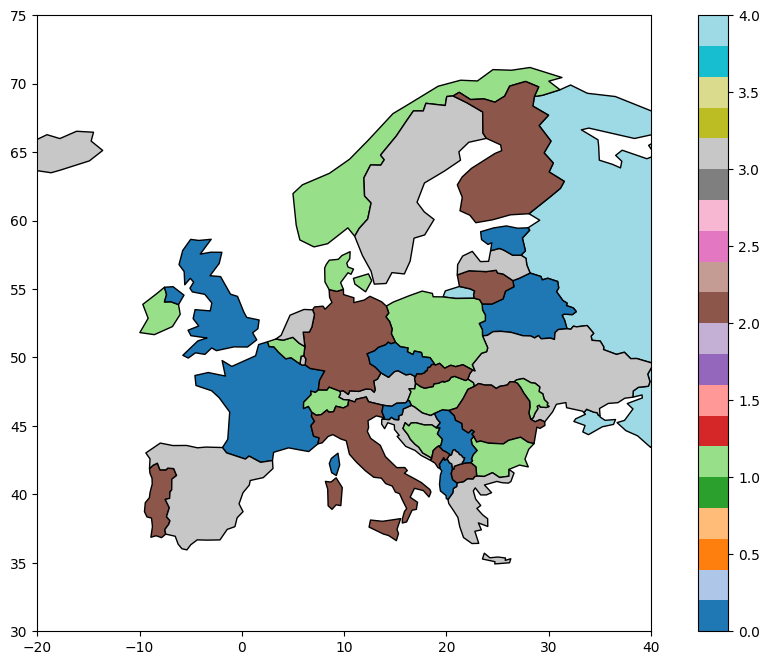

In [ ]:
# Plot the map
fig, ax = plt.subplots(figsize=(12,8))
europe.plot(column='color', cmap='tab20', legend=True, edgecolor='black', ax=ax)

# Define map limits to fit Europe map
ax.set_xlim(-20, 40)
ax.set_ylim(30, 75)

plt.show()